In [6]:
from python_files.ImageSegmentation import GetConnectedComponents, Kmeans_Clustering, GetWatershedByImmersion, GetWatershedFromMarks
import matplotlib.pyplot as plt
import cv2 as cv

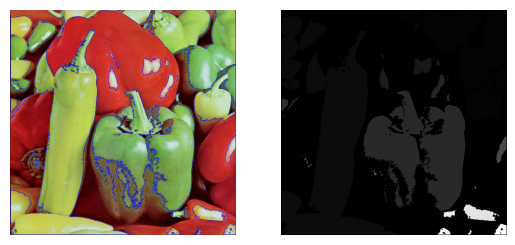

In [7]:
img_orig = cv.imread("Aula_3_files/peppers.jpg")
img_orig = cv.cvtColor(img_orig, cv.COLOR_BGR2RGB)

img = img_orig.copy()
processed = GetConnectedComponents(img)

img[processed == 0] = [0, 0, 255]

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(processed, cmap="gray")
plt.axis('off')
plt.show()

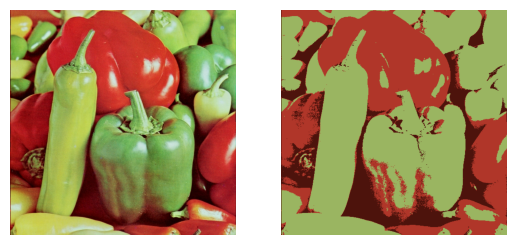

In [8]:
kmeans_processed = Kmeans_Clustering(img_orig, 3)

plt.subplot(1, 2, 1)
plt.imshow(img_orig)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(kmeans_processed, cmap="gray")
plt.axis('off')
plt.show()

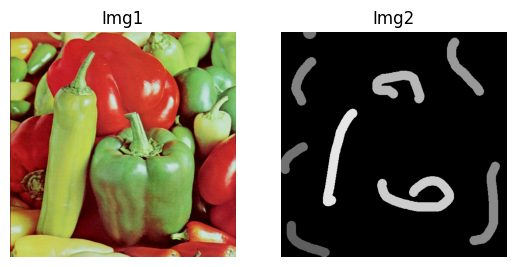

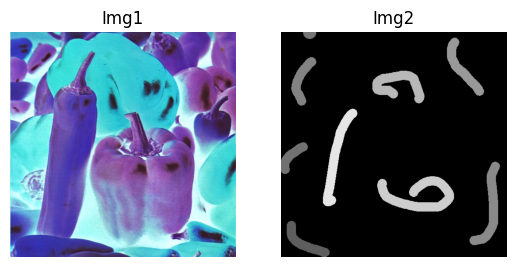

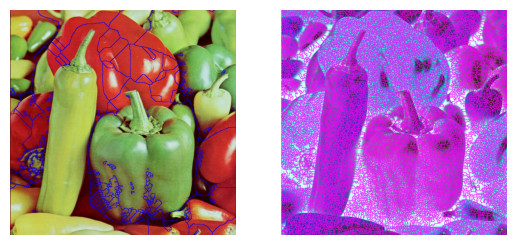

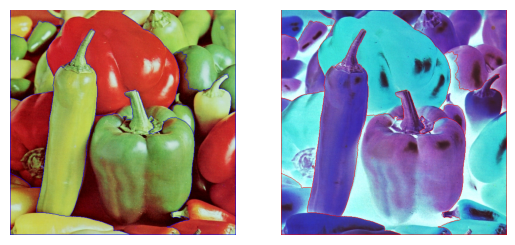

In [9]:
img_inv = cv.bitwise_not(img_orig)
marks = cv.imread("Aula_3_files/peppers.jpg.mask.bmp")


watterShedImm = GetWatershedByImmersion(kmeans_processed)
watterShedImm_inv = GetWatershedByImmersion(img_inv)

watterShedMark = GetWatershedFromMarks(img_orig, marks)
watterShedMark_inv = GetWatershedFromMarks(img_inv, marks)

watterShedImmOverlap = img_orig.copy()
watterShedImmOverlap[watterShedImm == 0] = [0, 0, 255]

watterShedImmOverlap_inv = img_inv.copy()
watterShedImmOverlap_inv[watterShedImm_inv == 0] = [255, 0, 255]

watterShedMarkOverlap = img_orig.copy()
watterShedMarkOverlap[watterShedMark == 0] = [0, 0, 255]

watterShedMarkOverlap_inv = img_inv.copy()
watterShedMarkOverlap_inv[watterShedMark_inv == 0] = [255, 0, 0]

plt.subplot(1, 2, 1)
plt.imshow(watterShedImmOverlap, cmap="gray")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(watterShedImmOverlap_inv, cmap="gray")
plt.axis('off')
plt.show()

plt.subplot(1, 2, 1)
plt.imshow(watterShedMarkOverlap, cmap="gray")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(watterShedMarkOverlap_inv, cmap="gray")
plt.axis('off')
plt.show()